# Header

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import cmdstanpy
import arviz as az

In [ ]:
n_chains = 2
iter_warmup = 400
iter_sampling = 400

In [3]:
import boto3
from configparser import ConfigParser
import awswrangler as wr

config = ConfigParser()
config.read(r'C:\Users\RyanKarel\.aws\credentials')

boto3_session = boto3.session.Session(
    aws_access_key_id=config['218527194748_ActuaryAccessProd']['aws_access_key_id'],
    aws_secret_access_key=config['218527194748_ActuaryAccessProd']['aws_secret_access_key'],
    aws_session_token=config['218527194748_ActuaryAccessProd']['aws_session_token'],
    region_name='us-east-1',
)

def query_athena(
    sql: str,
    boto3_session,
    database: str = "rn_actuary_db",
    workgroup: str = "Actuary",
    index_col = None,
    check_index_uniqueness: bool = True,
    force_index_uniqueness: bool = False,
) -> pd.DataFrame:
    output = wr.athena.read_sql_query(
        sql=sql,
        database=database,
        boto3_session=boto3_session,
        workgroup=workgroup,
        ctas_approach=False,
    )
    if index_col is not None:
        if force_index_uniqueness:
            output.drop_duplicates(subset=index_col, inplace=True)
        output.set_index(index_col, inplace=True)
        if check_index_uniqueness:
            assert output.index.is_unique
    return output

## Query

Here's the query I'm using for this analysis.

```sql
with claims_detail as (
    select
        p.num_policy,
        c.num_claim,
        1 as count_claim,
        case when cd_claim_status = 'Closed' then 1 else 0 end as count_closed_claim
    from tbl_claim c
    inner join tbl_policy p
        on c.num_policy = p.num_policy
    -- IMPORTANT: filtering out closed with small amounts of paid
    where
        not (cd_claim_status = 'Closed' and c.amt_total_incurred <= 5000)
        and p.cd_product in ('GC', 'SGC', 'CN', 'SCN')
),

policy_level_claims as (
    select
        num_policy,
        sum(count_claim) as count_claim,
        sum(count_closed_claim) as count_closed_claim
    from claims_detail
    group by 1
),

exposures as (
    select
        num_policy,
        coalesce(cd_exposure_type_group, 'Unknown') as cd_exposure_type_group,
        sum(try_cast(amt_exposure as bigint)) as amt_exposure
    from tbl_exposure
    group by 1, 2
),

exposures_at_policy_grain as (
    select
        num_policy,
        map_agg(cd_exposure_type_group, amt_exposure) as map_exposure_profile
    from exposures
    group by 1
)

select
    num_policy,
    dt_policy_effective,
    coalesce(dt_cancellation, dt_policy_expiration) as dt_policy_expiration,
    date_diff('day', dt_policy_effective, current_timestamp) / 365.0 as age_since_effective,
    date_diff('day', coalesce(dt_cancellation, dt_policy_expiration), current_timestamp) / 365.0 as age_since_expiration,
    coalesce(c.count_claim, 0) as count_claim,
    coalesce(c.count_closed_claim, 0) as count_closed_claim,
    lc.cd_largest_class,
    lcg.cd_group_name as cd_largest_class_group,
    map_exposure_profile['Sales'] as amt_sales,
    map_exposure_profile['Payroll'] as amt_payroll,
    map_exposure_profile['Units'] as amt_units,
    map_exposure_profile['Square Feet'] as amt_square_feet,
    map_exposure_profile['Cost'] as amt_cost,
    p.cd_product,
    p.num_policy_term_length / 365.0 as amt_term_factor
from tbl_policy p
left join policy_level_claims c using (num_policy)
left join tbl_largest_class lc using (num_policy)
left join vw_largest_class_group lcg using (num_policy)
left join exposures_at_policy_grain e using (num_policy)
where
    -- disallowed exposure types for ease
    map_exposure_profile['Children'] is null and
    map_exposure_profile['Acres'] is null and
    map_exposure_profile['Miles'] is null and
    map_exposure_profile['Gallons'] is null
    and p.cd_product in ('GC', 'SGC', 'CN', 'SCN')
```

# Data Prep

In [ ]:
data = query_athena(
    """
with claims_detail as (
    select
        p.num_policy,
        c.num_claim,
        1 as count_claim,
        case when cd_claim_status = 'Closed' then 1 else 0 end as count_closed_claim
    from tbl_claim c
    inner join tbl_policy p
        on c.num_policy = p.num_policy
    -- IMPORTANT: filtering out closed with small amounts of paid
    where
        not (cd_claim_status = 'Closed' and c.amt_total_incurred <= 1)
        and coalesce(p.amt_total_attachment, 0) = 0 -- primary layer only
        and p.cd_product not in ('CP', 'IM') -- non property
),

policy_level_claims as (
    select
        num_policy,
        sum(count_claim) as count_claim,
        sum(count_closed_claim) as count_closed_claim
    from claims_detail
    group by 1
),

exposures as (
    select
        num_policy,
        coalesce(cd_exposure_type_group, 'Unknown') as cd_exposure_type_group,
        sum(try_cast(amt_exposure as bigint)) as amt_exposure
    from tbl_exposure
    group by 1, 2
),

exposures_at_policy_grain as (
    select
        num_policy,
        map_agg(cd_exposure_type_group, amt_exposure) as map_exposure_profile
    from exposures
    group by 1
)

select
    num_policy,
    dt_policy_effective,
    coalesce(dt_cancellation, dt_policy_expiration) as dt_policy_expiration,
    date_diff('day', dt_policy_effective, current_timestamp) / 365.0 as age_since_effective,
    date_diff('day', coalesce(dt_cancellation, dt_policy_expiration), current_timestamp) / 365.0 as age_since_expiration,
    coalesce(c.count_claim, 0) as count_claim,
    coalesce(c.count_closed_claim, 0) as count_closed_claim,
    lc.cd_largest_class,
    lcg.cd_group_name as cd_largest_class_group,
    cd_primary_risk_state,
    map_exposure_profile['Sales'] as amt_sales,
    map_exposure_profile['Payroll'] as amt_payroll,
    map_exposure_profile['Units'] as amt_units,
    map_exposure_profile['Square Feet'] as amt_square_feet,
    map_exposure_profile['Cost'] as amt_cost,
    p.cd_product,
    p.num_policy_term_length / 365.0 as amt_term_factor
from tbl_policy p
left join policy_level_claims c using (num_policy)
left join tbl_largest_class lc using (num_policy)
left join vw_largest_class_group lcg using (num_policy)
left join exposures_at_policy_grain e using (num_policy)
where
    -- disallowed exposure types for ease
    map_exposure_profile['Children'] is null and
    map_exposure_profile['Acres'] is null and
    map_exposure_profile['Miles'] is null and
    map_exposure_profile['Gallons'] is null
    and p.cd_product in ('GC', 'SGC', 'CN', 'SCN')
    """,
    boto3_session=boto3_session
)
data = data.loc[data['cd_largest_class_group'].notnull()]
data = data.loc[data.loc[:, 'amt_sales':'amt_cost'].fillna(0).sum(axis=1) > 0]
data = data.loc[data.loc[:, 'amt_term_factor'].fillna(0) > 0]
data = data.loc[data.loc[:, 'dt_policy_expiration'] < pd.Timestamp('now').date()]
data.set_index('num_policy', inplace=True)
data['idx_policy'] = np.arange(1, len(data) + 1)
data

,dt_policy_effective,dt_policy_expiration,age_since_effective,age_since_expiration,count_claim,count_closed_claim,cd_largest_class,cd_largest_class_group,cd_primary_risk_state,amt_sales,amt_payroll,amt_units,amt_square_feet,amt_cost,cd_product,amt_term_factor,idx_policy
num_policy,,,,,,,,,,,,,,,,,
RN-7-0324263,2022-05-31,2023-05-31,4.208219,3.208219,0,0,62003,Condominiums,FL,<NA>,<NA>,98,35000,<NA>,GC,1.0,1
RN-7-0324331,2022-06-22,2023-06-22,4.147945,3.147945,1,1,60010,Apartments,FL,<NA>,<NA>,520,<NA>,<NA>,GC,1.0,2
RN-7-0324338,2022-06-23,2022-07-07,4.145205,4.106849,0,0,91342,Carpentry,FL,<NA>,210000,<NA>,<NA>,<NA>,CN,1.0,3
RN-7-0324884,2022-10-18,2023-10-18,3.824658,2.824658,0,0,62003,Condominiums,FL,<NA>,<NA>,165,800,<NA>,GC,1.0,4
RN-7-0324887,2022-10-17,2023-09-06,3.827397,2.939726,0,0,94007,Digging,TX,<NA>,53750,<NA>,<NA>,<NA>,CN,1.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RN-7-0511192,2025-05-03,2026-05-03,1.282192,0.282192,0,0,91340,Carpentry,FL,<NA>,100000,<NA>,<NA>,1200000,CN,1.0,7508
RN-7-0512049,2025-06-16,2026-06-16,1.161644,0.161644,0,0,45192,Hotels and Motels,GA,500000,<NA>,<NA>,6500,<NA>,SGC,1.0,7509
RN-7-0512870,2025-07-31,2026-07-31,1.038356,0.038356,0,0,91580,Other Contracting,CT,500000,<NA>,<NA>,<NA>,<NA>,SCN,1.0,7510


In [ ]:
claims = query_athena("""
    select
        p.num_policy,
        c.num_claim,
        1 as count_claim,
        case when cd_claim_status = 'Closed' then 1 else 0 end as count_closed_claim,
        date_diff('day', dt_claim_occurrence, dt_claim_report) / 365.0 as amt_report_lag
    from tbl_claim c
    inner join tbl_policy p
        on c.num_policy = p.num_policy
    -- IMPORTANT: filtering out closed with small amounts of paid
    where
        not (cd_claim_status = 'Closed' and c.amt_total_incurred <= 5000)
        and p.cd_product in ('GC', 'SGC', 'CN', 'SCN')
        and dt_claim_occurrence > p.dt_policy_effective
    """,
    boto3_session=boto3_session
)
claims = claims.merge(data[['idx_policy', 'age_since_effective']], how='inner', left_on='num_policy', right_index=True)
claims

,num_policy,num_claim,count_claim,count_closed_claim,amt_report_lag,idx_policy,age_since_effective
0,RN-7-0324266,RN-9-0000111,1,1,0.005479,4360,4.205479
1,RN-7-0324267,RN-9-0000121,1,1,0.013699,4247,4.205479
2,RN-7-0325100,RN-9-0000158,1,1,0.052055,3652,3.704110
3,RN-7-0324986,RN-9-0000166,1,1,0.150685,1315,3.780822
4,RN-7-0324281,RN-9-0000202,1,1,0.202740,6063,4.186301
...,...,...,...,...,...,...,...
1007,RN-7-0500734-02,RN-9-0004111,1,0,0.126027,1479,1.123288
1010,RN-7-0502653-01,RN-9-0004130,1,0,0.282192,4453,1.739726
1013,RN-7-0504052-01,RN-9-0004155,1,0,0.586301,3539,1.457534
1016,RN-7-0501622,RN-9-0004168,1,0,2.882192,4261,2.909589


In [6]:
exposure = data.loc[:, 'amt_sales':'amt_cost'].fillna(0).mul(data.loc[:, 'amt_term_factor'], axis=0)
class_code = data.loc[:, 'cd_largest_class_group'].astype('category')
risk_state = data.loc[:, 'cd_primary_risk_state'].astype('category')
frequency = data.loc[:, 'count_claim'] # reported basis
term_length = data.loc[:, 'amt_term_factor'] # reported basis
policy_age = data.loc[:, 'age_since_effective'] # reported basis
exposure

,amt_sales,amt_payroll,amt_units,amt_square_feet,amt_cost
num_policy,,,,,
RN-7-0324263,0.0,0.0,98.0,35000.0,0.0
RN-7-0324331,0.0,0.0,520.0,0.0,0.0
RN-7-0324338,0.0,210000.0,0.0,0.0,0.0
RN-7-0324884,0.0,0.0,165.0,800.0,0.0
RN-7-0324887,0.0,53750.0,0.0,0.0,0.0
...,...,...,...,...,...
RN-7-0511192,0.0,100000.0,0.0,0.0,1200000.0
RN-7-0512049,500000.0,0.0,0.0,6500.0,0.0
RN-7-0512870,500000.0,0.0,0.0,0.0,0.0


In [7]:
# scale exposure by the avg amongst records that have non-zero values
exposure_avg_scale = pd.Series(index=exposure.columns)
for col in exposure:
    exposure_avg_scale.loc[col] = exposure.query(f"{col} > 0")[col].mean()
scaled_exposure = exposure / exposure_avg_scale
scaled_exposure.describe()

,amt_sales,amt_payroll,amt_units,amt_square_feet,amt_cost
count,7512.0,7512.0,7512.0,7512.0,7512.0
mean,0.299121,0.374201,0.327343,0.160011,0.269968
std,0.994193,1.111916,1.034949,0.909758,1.169095
min,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0
75%,0.272121,0.413869,0.244132,0.0,0.018255
max,40.974624,52.081202,24.302659,25.654306,37.867599


In [8]:
observed_data = (
    data[['idx_policy']]
    .reset_index()
    .merge(
        (
            claims
            .groupby('idx_policy')
            .size()
            .rename('reported_claims')
        ),
        how='left',
        on='idx_policy'
    )
    .set_index('num_policy')
    .loc[data.index]
    ['reported_claims']
    .fillna(0)
    .astype(int)
)
observed_data.value_counts()

reported_claims
0     6912
1      486
2       74
3       26
4        8
5        4
7        1
10       1
Name: count, dtype: int64

# Model

## Fixed effect model

In [9]:
reported_frequency = cmdstanpy.CmdStanModel(stan_file='reported_frequency.stan')

In [10]:
N, E_cols = scaled_exposure.shape
idx_class_code = class_code.cat.codes + 1
idx_risk_state = risk_state.cat.codes + 1
K_class = idx_class_code.max()
K_state = idx_risk_state.max()
stan_data = {
    'N': N,
    'E_cols': E_cols,
    'K_class': K_class,
    'K_state': K_state,
    'E': scaled_exposure,
    't': term_length,
    'policy_age': policy_age,
    'g_class': idx_class_code,
    'g_state': idx_risk_state,
    'C_rows': len(claims),
    'idx_policy': claims['idx_policy'],
    'R': np.maximum(claims['amt_report_lag'], 1/365),
    'prior_only': 0,
}

In [11]:
# cmdstanpy.install_cmdstan(compiler=True)

In [12]:
mcmc_inits = {
    'lambda_0': 1.0,
    'lambda_E': [0.1] * E_cols,
    'R_shape': 1.0,
    'R_scale': 0.5,
    'C_R_phi': 1.0,
    'sigma_class': 0.01,
    'sigma_state': 0.01,
    'z_class': [0.0] * K_class,
    'z_state': [0.0] * K_state,
}

print("Begin posterior distribution sampling.")
posterior_basic = reported_frequency.sample(
    data=stan_data,
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits
)

Begin posterior distribution sampling.


09:47:17 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/800 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/800 [00:00<?, ?it/s, (Warmup)]

09:48:23 - cmdstanpy - INFO - CmdStan done processing.
09:48:23 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: Exception: weibull_cdf: Scale parameter is inf, but must be positive finite! (in 'reported_frequency.stan', line 6, column 12 to column 57) (in 'reported_frequency.stan', line 53, column 4 to column 79)
Exception: Exception: weibull_cdf: Shape parameter is 0, but must be positive finite! (in 'reported_frequency.stan', line 6, column 12 to column 57) (in 'reported_frequency.stan', line 53, column 4 to column 79)
Consider re-running with show_console=True if the above output is unclear!


In [13]:
# develop InferenceData and run diagnostics on that
# add in class group variable
inference_data_basic = az.from_cmdstanpy(
    posterior=posterior_basic,
    posterior_predictive='C_R_post_pred',
    observed_data={'C_R_post_pred': observed_data},
    log_likelihood={'C_R_post_pred': 'C_R_log_lik'},
    dims={
        'lambda_E': ['exposure_type'],
        'log_beta_class': ['class_code'],
        'log_beta_state': ['risk_state'],
        'E': ['obs_id', 'exposure_type'],
        'g_class': ['obs_id'],
        'g_state': ['obs_id'],
        'C_R_mean': ['obs_id'],
        'C_R_post_pred': ['obs_id'],
        'C_R_log_lik': ['obs_id']
    },
    coords={
        'exposure_type': ['sales', 'payroll', 'units', 'square_feet', 'cost'],
        'class_code': class_code.cat.categories.tolist(),
        'risk_state': risk_state.cat.categories.tolist(),
        'obs_id': data.index.tolist()
    },
    dtypes={
        'C_R_post_pred': 'int'
    }
)

## Bad Normal Model for Illustration Purposes

In [63]:
bad_normal = cmdstanpy.CmdStanModel(stan_file='reported_frequency_bad_normal_example.stan')
posterior_bad = bad_normal.sample(
    data=stan_data,
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits
)
inference_data_bad = az.from_cmdstanpy(
    posterior=posterior_bad,
    posterior_predictive='C_R_post_pred',
    observed_data={'C_R_post_pred': observed_data},
    log_likelihood={'C_R_post_pred': 'C_R_log_lik'},
    dims={
        'lambda_E': ['exposure_type'],
        'log_beta_class': ['class_code'],
        'log_beta_state': ['risk_state'],
        'E': ['obs_id', 'exposure_type'],
        'g_class': ['obs_id'],
        'g_state': ['obs_id'],
        'C_R_mean': ['obs_id'],
        'C_R_post_pred': ['obs_id'],
        'C_R_log_lik': ['obs_id']
    },
    coords={
        'exposure_type': ['sales', 'payroll', 'units', 'square_feet', 'cost'],
        'class_code': class_code.cat.categories.tolist(),
        'risk_state': risk_state.cat.categories.tolist(),
        'obs_id': data.index.tolist()
    },
    dtypes={
        'C_R_post_pred': 'int'
    }
)

13:09:45 - cmdstanpy - INFO - compiling stan file C:\Users\RYANKA~1\AGGREG~1\reported_frequency_bad_normal_example.stan to exe file C:\Users\RyanKarel\Aggregate Loss Cost Modeling\reported_frequency_bad_normal_example.exe
13:14:33 - cmdstanpy - INFO - compiled model executable: C:\Users\RyanKarel\Aggregate Loss Cost Modeling\reported_frequency_bad_normal_example.exe
13:14:35 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/800 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/800 [00:00<?, ?it/s, (Warmup)]

13:14:43 - cmdstanpy - INFO - CmdStan done processing.
13:14:43 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'reported_frequency_bad_normal_example.stan', line 39, column 8 to column 32)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'reported_frequency_bad_normal_example.stan', line 39, column 8 to column 32)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'reported_frequency_bad_normal_example.stan', line 39, column 8 to column 32)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'reported_frequency_bad_normal_example.stan', line 39, column 8 to column 32)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'reported_frequency_bad_normal_example.stan', line 39, column 8 to column 32)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'reported_frequency_bad_normal_example.stan', line 39

## Cross-classified model

In [14]:
cross_classified = cmdstanpy.CmdStanModel(stan_file='reported_frequency_cross_classified.stan')

09:48:36 - cmdstanpy - INFO - compiling stan file C:\Users\RYANKA~1\AGGREG~1\reported_frequency_cross_classified.stan to exe file C:\Users\RyanKarel\Aggregate Loss Cost Modeling\reported_frequency_cross_classified.exe
09:55:04 - cmdstanpy - INFO - compiled model executable: C:\Users\RyanKarel\Aggregate Loss Cost Modeling\reported_frequency_cross_classified.exe


In [15]:
N, E_cols = scaled_exposure.shape
idx_class_code = class_code.cat.codes + 1
idx_risk_state = risk_state.cat.codes + 1
K_class = idx_class_code.max()
K_state = idx_risk_state.max()
stan_data = {
    'N': N,
    'E_cols': E_cols,
    'K_class': K_class,
    'K_state': K_state,
    'E': scaled_exposure,
    't': term_length,
    'policy_age': policy_age,
    'g_class': idx_class_code,
    'g_state': idx_risk_state,
    'C_rows': len(claims),
    'idx_policy': claims['idx_policy'],
    'R': np.maximum(claims['amt_report_lag'], 1/365),
    'prior_only': 0,
    'include_frequency_trend': 1
}

### Without Trend

In [16]:
mcmc_inits = {
    'lambda_0': 1.0,
    'lambda_E': [0.1] * E_cols,
    'R_shape': 1.0,
    'R_scale': 0.5,
    'C_R_phi': 1.0,
    'sigma_class': 0.01,
    'sigma_state': 0.01,
    'z_class': [0.0] * K_class,
    'z_state': [0.0] * K_state,
    'frequency_trend_rate': 0.0
}

print("Begin posterior distribution sampling.")
posterior_cc_no_trend = cross_classified.sample(
    data={**stan_data, 'include_frequency_trend': 0},
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits
)

Begin posterior distribution sampling.


09:55:06 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/800 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/800 [00:00<?, ?it/s, (Warmup)]

09:57:53 - cmdstanpy - INFO - CmdStan done processing.
09:57:53 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: Exception: weibull_lcdf: Scale parameter is inf, but must be positive finite! (in 'reported_frequency_cross_classified.stan', line 6, column 12 to column 58) (in 'reported_frequency_cross_classified.stan', line 59, column 4 to column 80)
Exception: Exception: weibull_lcdf: Scale parameter is inf, but must be positive finite! (in 'reported_frequency_cross_classified.stan', line 6, column 12 to column 58) (in 'reported_frequency_cross_classified.stan', line 59, column 4 to column 80)
Consider re-running with show_console=True if the above output is unclear!


In [17]:
# develop InferenceData and run diagnostics on that
# add in class group variable
inference_data_cc_no_trend = az.from_cmdstanpy(
    posterior=posterior_cc_no_trend,
    posterior_predictive='C_R_post_pred',
    observed_data={'C_R_post_pred': observed_data},
    log_likelihood={'C_R_post_pred': 'C_R_log_lik'},
    dims={
        'lambda_E': ['exposure_type'],
        'log_beta_class': ['class_code'],
        'log_beta_state': ['risk_state'],
        'E': ['obs_id', 'exposure_type'],
        'g_class': ['obs_id'],
        'g_state': ['obs_id'],
        'C_R_mean': ['obs_id'],
        'C_R_post_pred': ['obs_id'],
        'C_R_log_lik': ['obs_id']
    },
    coords={
        'exposure_type': ['sales', 'payroll', 'units', 'square_feet', 'cost'],
        'class_code': class_code.cat.categories.tolist(),
        'risk_state': risk_state.cat.categories.tolist(),
        'obs_id': data.index.tolist()
    },
    dtypes={
        'C_R_post_pred': 'int'
    }
)

### With trend

In [18]:
cross_classified_trended = cmdstanpy.CmdStanModel(stan_file='reported_frequency_cross_classified_trended.stan')

09:58:07 - cmdstanpy - INFO - compiling stan file C:\Users\RYANKA~1\AGGREG~1\reported_frequency_cross_classified_trended.stan to exe file C:\Users\RyanKarel\Aggregate Loss Cost Modeling\reported_frequency_cross_classified_trended.exe
10:02:27 - cmdstanpy - INFO - compiled model executable: C:\Users\RyanKarel\Aggregate Loss Cost Modeling\reported_frequency_cross_classified_trended.exe


In [19]:
print("Begin posterior distribution sampling.")
posterior_cc_trended = cross_classified_trended.sample(
    data=stan_data,
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits
)

print("Begin prior distribution sampling.")
prior_cc_trended = cross_classified_trended.sample(
    data=stan_data,
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits
)

Begin posterior distribution sampling.


10:02:31 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/800 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/800 [00:00<?, ?it/s, (Warmup)]

10:06:28 - cmdstanpy - INFO - CmdStan done processing.
10:06:28 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: Exception: weibull_lcdf: Scale parameter is inf, but must be positive finite! (in 'reported_frequency_cross_classified_trended.stan', line 6, column 12 to column 58) (in 'reported_frequency_cross_classified_trended.stan', line 60, column 4 to column 80)
	Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is nan, but must be finite! (in 'reported_frequency_cross_classified_trended.stan', line 96, column 8 to column 56)
	Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is nan, but must be finite! (in 'reported_frequency_cross_classified_trended.stan', line 96, column 8 to column 56)
	Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is nan, but must be finite! (in 'reported_frequency_cross_classified_trended.stan', line 96, column 8 to column 56)
Exception: Exception: weibull_lcdf: Scale parameter is inf, but must be posit


Begin prior distribution sampling.


10:06:35 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/800 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/800 [00:00<?, ?it/s, (Warmup)]

10:10:44 - cmdstanpy - INFO - CmdStan done processing.
10:10:45 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: Exception: weibull_lcdf: Shape parameter is inf, but must be positive finite! (in 'reported_frequency_cross_classified_trended.stan', line 6, column 12 to column 58) (in 'reported_frequency_cross_classified_trended.stan', line 60, column 4 to column 80)
	Exception: Exception: weibull_lcdf: Shape parameter is inf, but must be positive finite! (in 'reported_frequency_cross_classified_trended.stan', line 6, column 12 to column 58) (in 'reported_frequency_cross_classified_trended.stan', line 60, column 4 to column 80)
	Exception: neg_binomial_2_log_lpmf: Log location parameter[7] is -inf, but must be finite! (in 'reported_frequency_cross_classified_trended.stan', line 96, column 8 to column 56)
	Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is nan, but must be finite! (in 'reported_frequency_cross_classified_trended.stan', line 96, column 8 to 

In [20]:
# develop InferenceData and run diagnostics on that
# add in class group variable
inference_data_cc_trended = az.from_cmdstanpy(
    posterior=posterior_cc_trended,
    posterior_predictive='C_R_post_pred',
    observed_data={'C_R_post_pred': observed_data},
    log_likelihood={'C_R_post_pred': 'C_R_log_lik'},
    dims={
        'lambda_E': ['exposure_type'],
        'log_beta_class': ['class_code'],
        'log_beta_state': ['risk_state'],
        'E': ['obs_id', 'exposure_type'],
        'g_class': ['obs_id'],
        'g_state': ['obs_id'],
        'C_R_mean': ['obs_id'],
        'C_R_post_pred': ['obs_id'],
        'C_R_log_lik': ['obs_id']
    },
    coords={
        'exposure_type': ['sales', 'payroll', 'units', 'square_feet', 'cost'],
        'class_code': class_code.cat.categories.tolist(),
        'risk_state': risk_state.cat.categories.tolist(),
        'obs_id': data.index.tolist()
    },
    dtypes={
        'C_R_post_pred': 'int'
    }
)

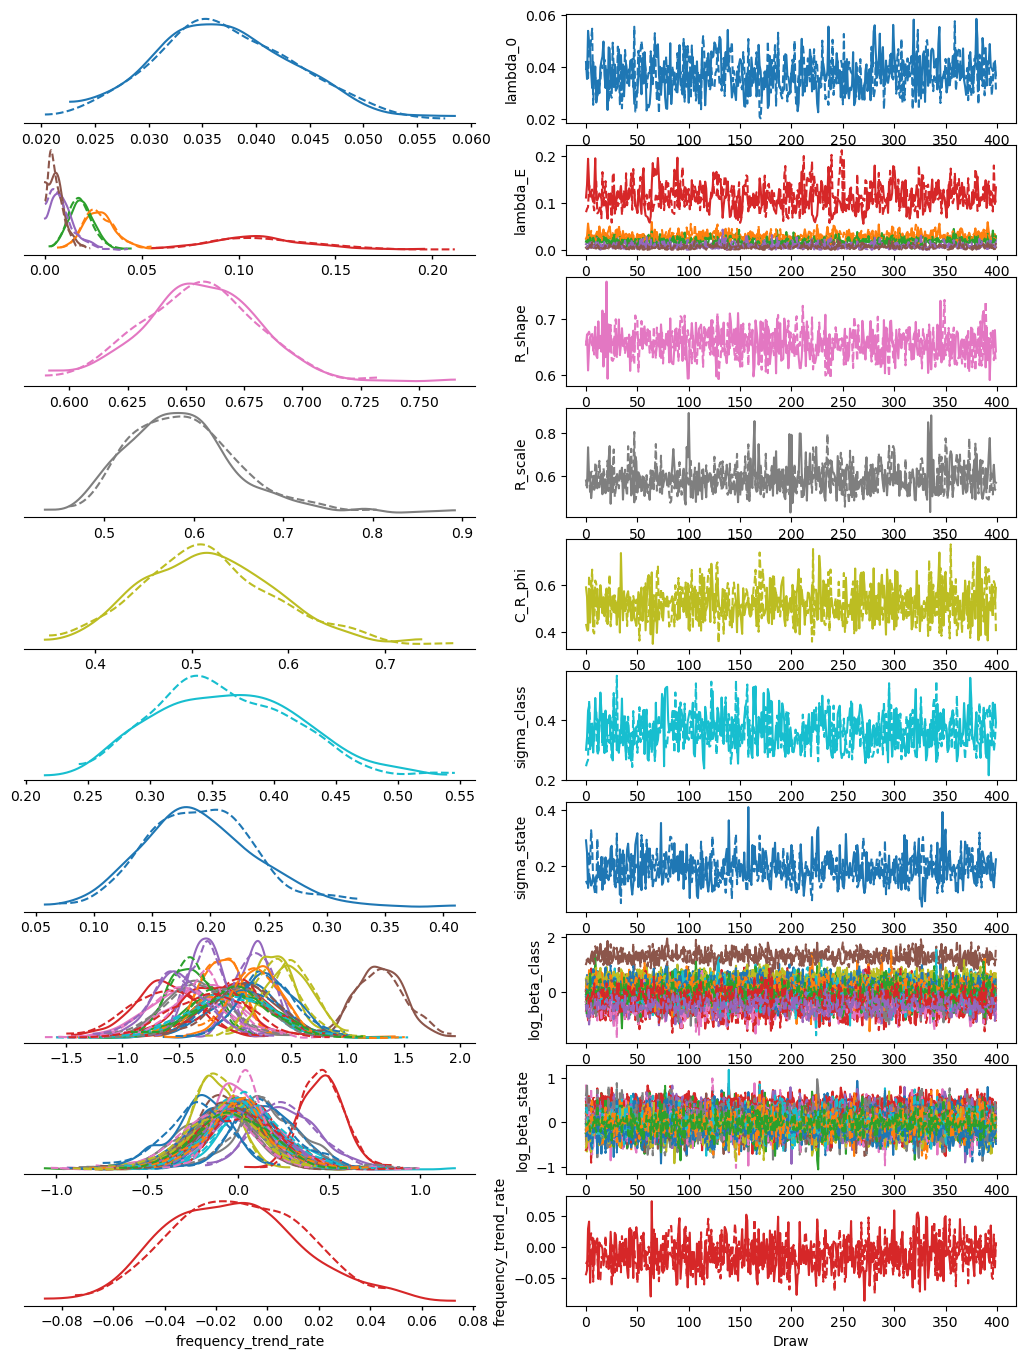

In [21]:
az.plot_trace_dist(
    inference_data_cc_trended,
    var_names=[
        'lambda_0',
        'lambda_E',
        'R_shape',
        'R_scale',
        'C_R_phi',
        'sigma_class',
        'sigma_state',
        'log_beta_class',
        'log_beta_state',
        'frequency_trend_rate'
    ]
)

In [23]:
# for comparison: non-CC model had ELPD LOO = -2356.3, so the CC appears to be better
az.loo(inference_data_cc_trended)

Computed from 800 posterior samples and 7512 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2267.24    74.52
p_loo       26.52        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.66]   (good)     7512  100.0%
   (0.66, 1]   (bad)         0    0.0%
    (1, Inf)   (very bad)    0    0.0%

### Zero inflation without trend 

In [24]:
zero_inflated = cmdstanpy.CmdStanModel(stan_file='reported_frequency_cross_classified_zero_inflation.stan')

10:11:51 - cmdstanpy - INFO - compiling stan file C:\Users\RYANKA~1\AGGREG~1\reported_frequency_cross_classified_zero_inflation.stan to exe file C:\Users\RyanKarel\Aggregate Loss Cost Modeling\reported_frequency_cross_classified_zero_inflation.exe
10:18:03 - cmdstanpy - INFO - compiled model executable: C:\Users\RyanKarel\Aggregate Loss Cost Modeling\reported_frequency_cross_classified_zero_inflation.exe


In [25]:
print("Begin posterior distribution sampling.")
posterior_cc_zi = zero_inflated.sample(
    data=stan_data,
    chains=n_chains,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    inits=mcmc_inits
)

Begin posterior distribution sampling.


10:18:05 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/800 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/800 [00:00<?, ?it/s, (Warmup)]

10:20:52 - cmdstanpy - INFO - CmdStan done processing.
10:20:53 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: Exception: weibull_lcdf: Scale parameter is inf, but must be positive finite! (in 'reported_frequency_cross_classified_zero_inflation.stan', line 6, column 12 to column 58) (in 'reported_frequency_cross_classified_zero_inflation.stan', line 86, column 4 to column 80)
Exception: Exception: neg_binomial_2_log_lpmf: Log location parameter is inf, but must be finite! (in 'reported_frequency_cross_classified_zero_inflation.stan', line 16, column 16 to line 19, column 18) (in 'reported_frequency_cross_classified_zero_inflation.stan', line 121, column 8 to column 82)
Consider re-running with show_console=True if the above output is unclear!


In [26]:
# develop InferenceData and run diagnostics on that
# add in class group variable
inference_data_zi = az.from_cmdstanpy(
    posterior=posterior_cc_zi,
    posterior_predictive='C_R_post_pred',
    prior=prior_cc_trended,
    prior_predictive='C_R_post_pred',
    observed_data={'C_R_post_pred': observed_data},
    log_likelihood={'C_R_post_pred': 'C_R_log_lik'},
    dims={
        'lambda_E': ['exposure_type'],
        'log_beta_class': ['class_code'],
        'log_beta_state': ['risk_state'],
        'E': ['obs_id', 'exposure_type'],
        'g_class': ['obs_id'],
        'g_state': ['obs_id'],
        'C_R_mean': ['obs_id'],
        'C_R_post_pred': ['obs_id'],
        'C_R_log_lik': ['obs_id']
    },
    coords={
        'exposure_type': ['sales', 'payroll', 'units', 'square_feet', 'cost'],
        'class_code': class_code.cat.categories.tolist(),
        'risk_state': risk_state.cat.categories.tolist(),
        'obs_id': data.index.tolist()
    },
    dtypes={
        'C_R_post_pred': 'int'
    }
)

## Comparison

In [64]:
az.compare(
    compare_dict={
        'basic_linear': inference_data_basic,
        'cross_classified_trended': inference_data_cc_trended,
        'cross_classified_no_trend': inference_data_cc_no_trend,
        'cross_classified_zero_inflated': inference_data_zi,
        'bad_normal': inference_data_bad
    },
    round_to=1
)

c:\Users\RyanKarel\anaconda3\envs\data-env-26-2\Lib\site-packages\arviz_stats\loo\helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.66 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd,p,elpd_diff,weight,se,dse,warning
cross_classified_trended,0,-2267.2,26.5,0.0,0.9,74.5,0.0,False
cross_classified_no_trend,1,-2267.5,26.0,-0.2,0.0,74.6,0.4,False
cross_classified_zero_inflated,2,-2267.8,25.8,-0.5,0.0,74.6,0.5,False
basic_linear,3,-2356.2,8.5,-89.0,0.0,77.9,15.0,False
bad_normal,4,-4125.2,39.6,-1858.0,0.1,401.3,363.0,True


In [71]:
selected_inference_data = inference_data_cc_no_trend

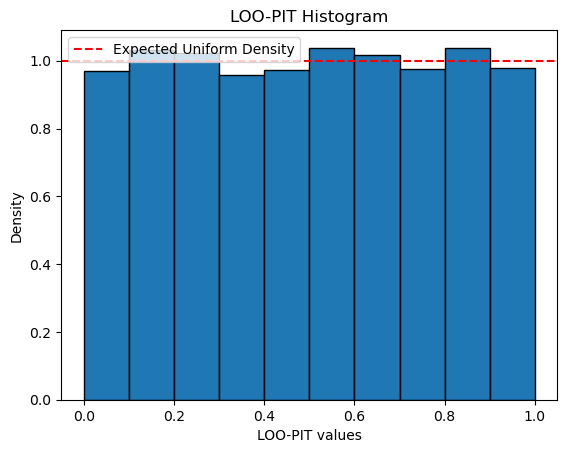

In [72]:
# histogram of LOO PIT values
loo_pit_vals = az.loo_pit(selected_inference_data, var_names="C_R_post_pred")['C_R_post_pred'].values

plt.hist(loo_pit_vals, bins=10, density=True, edgecolor="black")
plt.axhline(1.0, color="red", linestyle="--", label="Expected Uniform Density")
plt.xlabel("LOO-PIT values")
plt.ylabel("Density")
plt.title("LOO-PIT Histogram")
plt.legend()
plt.show()

<Axes: xlabel='uniform'>

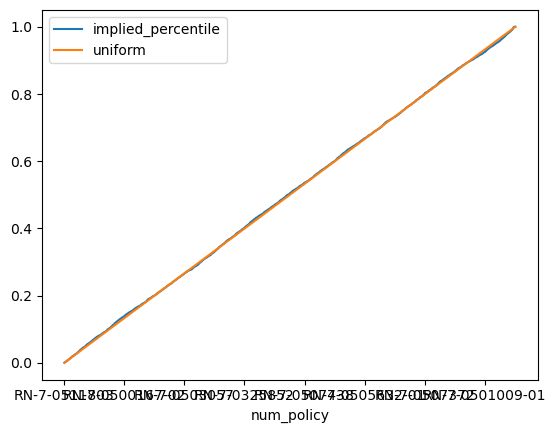

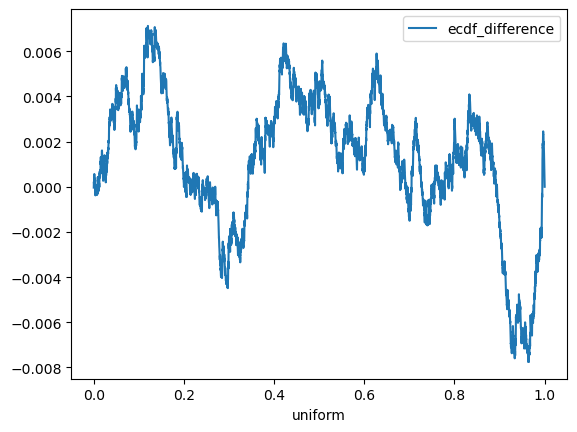

In [73]:
percentiles = pd.Series(loo_pit_vals, index=observed_data.index).sort_values().rename('implied_percentile')
uniform_comparison = (
    percentiles
    .to_frame()
    .assign(
        one=1,
        uniform=lambda x: x['one'].cumsum() / len(x),
        ecdf_difference=lambda x: x['implied_percentile'] - x['uniform']
    )
)
uniform_comparison.plot(y=['implied_percentile', 'uniform'])
uniform_comparison.plot(x='uniform', y='ecdf_difference')

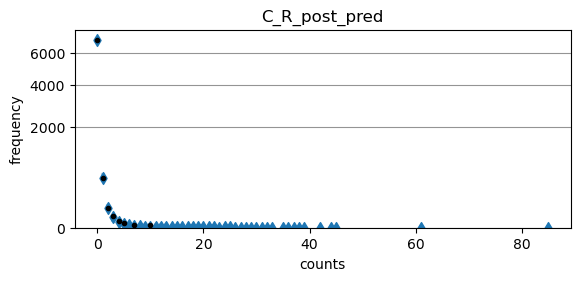

In [74]:
az.plot_ppc_rootogram(selected_inference_data)

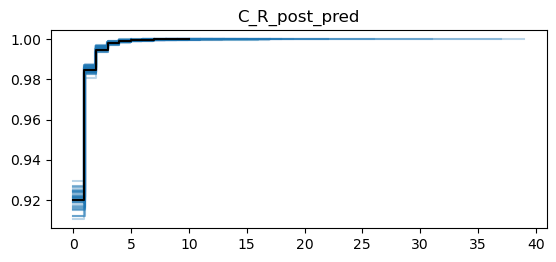

In [75]:
az.plot_ppc_dist(selected_inference_data, kind='ecdf')

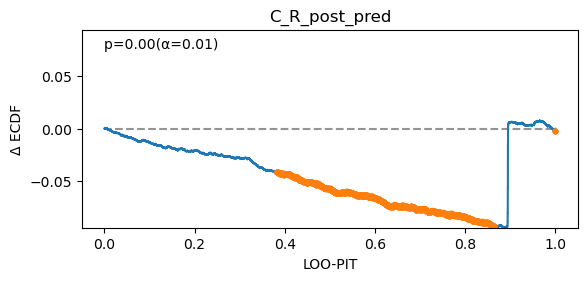

In [80]:
az.plot_loo_pit(selected_inference_data, var_names='C_R_post_pred')